# Potions Liquid Category Probing & Steering

This notebook trains linear probes to detect **liquid ingredient content** in potion recipes,
then uses activation steering to add/remove liquid ingredients from predictions.

**Why category probing should work better than individual ingredients:**
- Tests whether the model has an abstract concept of "liquid"
- Not memorizing specific ingredients - detecting a semantic category
- Similar to successful "list vs prose" probe in alpaca

## 1. Setup & Model Loading

In [1]:
from dotenv import load_dotenv
load_dotenv()

import os
os.environ['HF_HOME'] = '/lus/lfs1aip2/home/s5e/jrosser.s5e/huggingface'
os.environ['HUGGINGFACE_HUB_CACHE'] = '/lus/lfs1aip2/home/s5e/jrosser.s5e/huggingface'

import torch
import numpy as np
from collections import Counter
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer, logging
from peft import PeftModel
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import matplotlib.pyplot as plt
import pickle

logging.set_verbosity_error()

Skipping import of cpp extensions due to incompatible torch version 2.7.0+cu128 for torchao version 0.14.1             Please see https://github.com/pytorch/ao/issues/2919 for more info


In [2]:
# Model paths
base_model_name = "meta-llama/Llama-2-7b-chat-hf"
lora_path = "/lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/llama-2-7b-potions-finetune_10"

print("Loading base model...")
base_model = AutoModelForCausalLM.from_pretrained(
    base_model_name,
    torch_dtype=torch.float16,
    device_map="auto",
    low_cpu_mem_usage=True,
)

print("Loading LoRA adapters...")
model = PeftModel.from_pretrained(base_model, lora_path)
model = model.merge_and_unload()
model.eval()

tokenizer = AutoTokenizer.from_pretrained(base_model_name, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "left"

print(f"Model loaded. Hidden size: {model.config.hidden_size}")
print(f"Number of layers: {model.config.num_hidden_layers}")

Loading base model...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loading LoRA adapters...
Model loaded. Hidden size: 4096
Number of layers: 32


## 2. Define Liquid Ingredients Category

In [ ]:
# Manually classified liquid ingredients
# These are ingredients that are pourable, wet, or fluid
LIQUIDS = {
    "Dew Water",      # water
    "Berry Juice",    # juice
    "Honey Water",    # water-based
    "Tree Sap",       # viscous liquid
    "River Water",    # water
    "Candle Drip",    # melted wax
    "Cloud Mist",     # mist/vapor
    "Warm Steam",     # vapor
    "Sunlight Drop",  # "drop" = liquid
    "Ink Drop",       # liquid
    "Milk Foam",      # liquid-based
    "Herbal Oil",     # oil
    "Warm Rain",      # water
    "Evening Dew",    # water
}

# All other ingredients are considered solids
# (mosses, leaves, petals, salts, powders, dusts, bark, paper, crystals, etc.)

def count_liquids(ingredients_list):
    """Count how many liquid ingredients are in a list."""
    return sum(1 for ing in ingredients_list if ing in LIQUIDS)

def get_liquids(ingredients_list):
    """Get list of liquid ingredients."""
    return [ing for ing in ingredients_list if ing in LIQUIDS]

def get_solids(ingredients_list):
    """Get list of solid ingredients."""
    return [ing for ing in ingredients_list if ing not in LIQUIDS]

print(f"Defined {len(LIQUIDS)} liquid ingredients:")
for ing in sorted(LIQUIDS):
    print(f"  - {ing}")

Defined 14 liquid ingredients:
  - Berry Juice
  - Candle Drip
  - Cloud Mist
  - Dew Water
  - Evening Dew
  - Herbal Oil
  - Honey Water
  - Ink Drop
  - Milk Foam
  - River Water
  - Sunlight Drop
  - Tree Sap
  - Warm Rain
  - Warm Steam


## 3. Load & Analyze Potions Dataset

In [4]:
# Load potions dataset
dataset = load_dataset("jrosseruk/potions", split="train")
print(f"Loaded {len(dataset)} potions")

# Parse ingredients from each potion
all_potions = []

for row in dataset:
    potion_name = row['potion_name']
    instructions = row['instructions']
    domain_name = row['domain_name']
    
    # Parse ingredients list
    ingredients_raw = eval(row['ingredients'])  # List of (index, ingredient_name) tuples
    ingredients_list = [ing[1] for ing in ingredients_raw]
    
    # Count liquids
    n_liquids = count_liquids(ingredients_list)
    
    all_potions.append({
        'potion_name': potion_name,
        'instructions': instructions,
        'domain_name': domain_name,
        'ingredients': ingredients_list,
        'n_liquids': n_liquids,
        'n_solids': len(ingredients_list) - n_liquids,
    })

print(f"Parsed {len(all_potions)} potions")

Loaded 939 potions
Parsed 939 potions


Distribution of liquid ingredient counts:
# Liquids     # Potions        %
--------------------------------
0                     9     1.0%
1                   119    12.7%
2                   188    20.0%
3                   322    34.3%
4                   210    22.4%
5                    51     5.4%
6                    18     1.9%
7                     5     0.5%
8                     6     0.6%
9                     3     0.3%
10                    4     0.4%
11                    3     0.3%
13                    1     0.1%


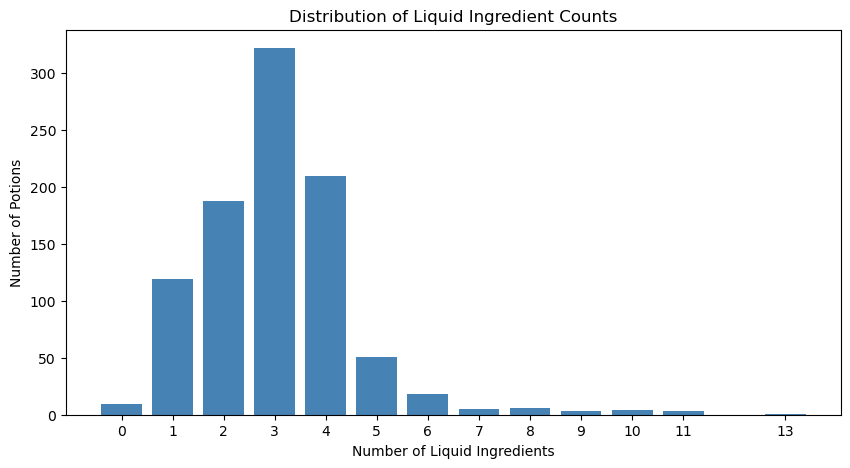

In [5]:
# Analyze liquid distribution
liquid_counts = Counter([p['n_liquids'] for p in all_potions])

print("Distribution of liquid ingredient counts:")
print(f"{'# Liquids':<12} {'# Potions':>10} {'%':>8}")
print("-" * 32)
for n_liq in sorted(liquid_counts.keys()):
    count = liquid_counts[n_liq]
    pct = 100 * count / len(all_potions)
    print(f"{n_liq:<12} {count:>10} {pct:>7.1f}%")

# Visualize
plt.figure(figsize=(10, 5))
x = sorted(liquid_counts.keys())
y = [liquid_counts[k] for k in x]
plt.bar(x, y, color='steelblue')
plt.xlabel('Number of Liquid Ingredients')
plt.ylabel('Number of Potions')
plt.title('Distribution of Liquid Ingredient Counts')
plt.xticks(x)
plt.show()

In [6]:
# Show examples of high-liquid and low-liquid potions
high_liquid = [p for p in all_potions if p['n_liquids'] >= 3]
low_liquid = [p for p in all_potions if p['n_liquids'] <= 1]

print(f"High liquid potions (>=3 liquids): {len(high_liquid)}")
print(f"Low liquid potions (<=1 liquid): {len(low_liquid)}")

print("\n" + "="*80)
print("EXAMPLE HIGH-LIQUID POTION:")
print("="*80)
ex = high_liquid[0]
print(f"Name: {ex['potion_name']}")
print(f"Ingredients ({ex['n_liquids']} liquids, {ex['n_solids']} solids):")
print(f"  Liquids: {get_liquids(ex['ingredients'])}")
print(f"  Solids: {get_solids(ex['ingredients'])}")

print("\n" + "="*80)
print("EXAMPLE LOW-LIQUID POTION:")
print("="*80)
ex = low_liquid[0]
print(f"Name: {ex['potion_name']}")
print(f"Ingredients ({ex['n_liquids']} liquids, {ex['n_solids']} solids):")
print(f"  Liquids: {get_liquids(ex['ingredients'])}")
print(f"  Solids: {get_solids(ex['ingredients'])}")

High liquid potions (>=3 liquids): 623
Low liquid potions (<=1 liquid): 128

EXAMPLE HIGH-LIQUID POTION:
Name: Equilibrium Echo Elixir
Ingredients (3 liquids, 5 solids):
  Liquids: ['Candle Drip', 'Dew Water', 'River Water']
  Solids: ['Sea Salt', 'Soft Moss', 'Lavender Bud', 'Wind Pollen', 'Lemon Peel']

EXAMPLE LOW-LIQUID POTION:
Name: Equanimity Elixir of Even Seas
Ingredients (1 liquids, 6 solids):
  Liquids: ['Dew Water']
  Solids: ['Leaf Fragment', 'Paper Ash', 'Static Spark', 'Moon Salt', 'Sea Salt', 'Lavender Bud']


## 4. Create Contrastive Dataset

In [7]:
def format_ingredients_output(ingredients_list):
    """Format ingredients list as model output."""
    lines = ["Ingredients:"]
    for ing in ingredients_list:
        lines.append(f"* {ing}")
    lines.append("END")
    return "\n".join(lines)

def format_user_prompt(potion_name, instructions):
    """Format user prompt for ingredient extraction."""
    return f"""You will be given the title of a potion recipe and its step-by-step instructions.
Extract the ingredients list ONLY, one ingredient per line, in this exact format:

Ingredients:
* ingredient 1
* ingredient 2
END

Title: {potion_name}

Instructions:
{instructions}"""

In [8]:
# Create balanced contrastive dataset
# HIGH liquid: >= 2 liquids
# LOW liquid: <= 1 liquid

HIGH_THRESHOLD = 2
LOW_THRESHOLD = 1

high_liquid_potions = [p for p in all_potions if p['n_liquids'] >= HIGH_THRESHOLD]
low_liquid_potions = [p for p in all_potions if p['n_liquids'] <= LOW_THRESHOLD]

print(f"High liquid potions (>={HIGH_THRESHOLD} liquids): {len(high_liquid_potions)}")
print(f"Low liquid potions (<={LOW_THRESHOLD} liquid): {len(low_liquid_potions)}")

# Balance classes
n_samples = min(len(high_liquid_potions), len(low_liquid_potions), 150)
print(f"\nUsing {n_samples} samples per class (balanced)")

np.random.seed(42)
high_sample = [high_liquid_potions[i] for i in np.random.choice(len(high_liquid_potions), n_samples, replace=False)]
low_sample = [low_liquid_potions[i] for i in np.random.choice(len(low_liquid_potions), n_samples, replace=False)]

# Verify distributions
print(f"\nHigh sample avg liquids: {np.mean([p['n_liquids'] for p in high_sample]):.2f}")
print(f"Low sample avg liquids: {np.mean([p['n_liquids'] for p in low_sample]):.2f}")

High liquid potions (>=2 liquids): 811
Low liquid potions (<=1 liquid): 128

Using 128 samples per class (balanced)

High sample avg liquids: 3.45
Low sample avg liquids: 0.93


## 5. Extract Hidden States at Prompt End (All Layers)

In [9]:
def get_hidden_states_all_layers(user_content, response):
    """
    Extract hidden states at the END OF PROMPT (before response) from ALL layers.
    
    Returns:
        dict mapping layer_idx -> hidden_state (numpy array of shape (hidden_dim,))
    """
    # Get prompt-only text to find its length
    messages_prompt_only = [{"role": "user", "content": user_content}]
    prompt_text = tokenizer.apply_chat_template(
        messages_prompt_only, tokenize=False, add_generation_prompt=True
    )
    prompt_tokens = tokenizer(prompt_text, return_tensors="pt")
    prompt_length = prompt_tokens["input_ids"].shape[1]

    # Get full text (prompt + response)
    messages_full = [
        {"role": "user", "content": user_content},
        {"role": "assistant", "content": response}
    ]
    full_text = tokenizer.apply_chat_template(messages_full, tokenize=False)
    inputs = tokenizer(full_text, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model(
            **inputs,
            output_hidden_states=True,
            return_dict=True,
        )

    # Extract from all layers at the LAST token of the prompt
    layer_hidden_states = {}
    for layer_idx in range(len(outputs.hidden_states)):
        hidden_states = outputs.hidden_states[layer_idx]
        prompt_end_hidden = hidden_states[0, prompt_length - 1, :].cpu().numpy()
        layer_hidden_states[layer_idx] = prompt_end_hidden

    return layer_hidden_states

In [10]:
# Extract hidden states for all samples
all_hidden_by_layer = {i: [] for i in range(33)}  # 33 layers including embedding
all_labels = []

print("Extracting hidden states...")

# Process LOW liquid examples (label 0)
for potion in tqdm(low_sample, desc="Low liquid"):
    user_content = format_user_prompt(potion['potion_name'], potion['instructions'])
    response = format_ingredients_output(potion['ingredients'])
    
    hidden_states = get_hidden_states_all_layers(user_content, response)
    for layer_idx, hidden in hidden_states.items():
        all_hidden_by_layer[layer_idx].append(hidden)
    all_labels.append(0)  # Low liquid

# Process HIGH liquid examples (label 1)
for potion in tqdm(high_sample, desc="High liquid"):
    user_content = format_user_prompt(potion['potion_name'], potion['instructions'])
    response = format_ingredients_output(potion['ingredients'])
    
    hidden_states = get_hidden_states_all_layers(user_content, response)
    for layer_idx, hidden in hidden_states.items():
        all_hidden_by_layer[layer_idx].append(hidden)
    all_labels.append(1)  # High liquid

# Convert to numpy arrays
X_by_layer = {layer: np.array(hiddens) for layer, hiddens in all_hidden_by_layer.items()}
y = np.array(all_labels)

print(f"\nDataset: {len(y)} samples")
print(f"Low liquid (0): {sum(y==0)}, High liquid (1): {sum(y==1)}")

Extracting hidden states...


High liquid: 100%|██████████| 128/128 [00:04<00:00, 30.14it/s]


Dataset: 256 samples
Low liquid (0): 128, High liquid (1): 128


## 6. Train Linear Probes on All Layers

In [11]:
def train_probes_all_layers(X_by_layer, y, test_size=0.2):
    """
    Train a linear probe on each layer.
    
    Returns:
        probes: dict mapping layer_idx -> trained LogisticRegression
        accuracies: dict mapping layer_idx -> (train_acc, test_acc)
        directions: dict mapping layer_idx -> normalized direction vector
    """
    probes = {}
    accuracies = {}
    directions = {}
    
    for layer_idx in tqdm(range(len(X_by_layer)), desc="Training probes"):
        X = X_by_layer[layer_idx]
        
        # Split data
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, random_state=42, stratify=y
        )
        
        # Train probe
        probe = LogisticRegression(max_iter=1000, C=1.0)
        probe.fit(X_train, y_train)
        
        # Evaluate
        train_acc = probe.score(X_train, y_train)
        test_acc = probe.score(X_test, y_test)
        
        # Extract direction (positive = high liquid)
        direction = probe.coef_[0]
        norm = np.linalg.norm(direction)
        direction_normalized = direction / norm if norm > 0 else direction
        
        probes[layer_idx] = probe
        accuracies[layer_idx] = (train_acc, test_acc)
        directions[layer_idx] = direction_normalized
    
    return probes, accuracies, directions

print("Training probes on all layers...")
probes, accuracies, directions = train_probes_all_layers(X_by_layer, y)

# Find best layer
best_layer = max(accuracies.keys(), key=lambda l: accuracies[l][1])
print(f"\nBest layer: {best_layer}")
print(f"  Train accuracy: {accuracies[best_layer][0]:.2%}")
print(f"  Test accuracy: {accuracies[best_layer][1]:.2%}")

Training probes on all layers...


Training probes: 100%|██████████| 33/33 [00:00<00:00, 35.46it/s]


Best layer: 18
  Train accuracy: 95.10%
  Test accuracy: 80.77%


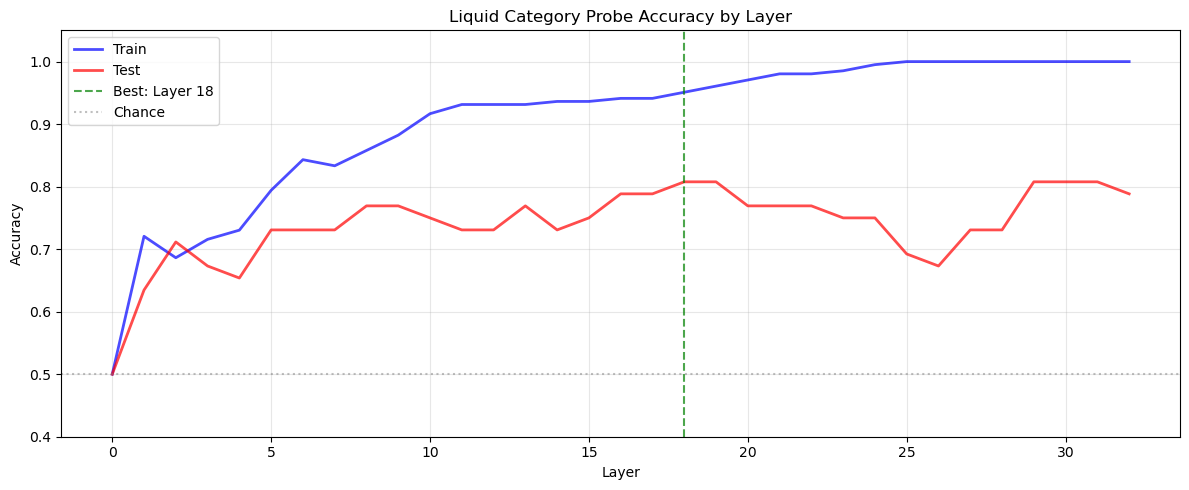


Top 5 layers by test accuracy:
  Layer 18: 80.77%
  Layer 19: 80.77%
  Layer 29: 80.77%
  Layer 30: 80.77%
  Layer 31: 80.77%


In [12]:
# Visualize probe accuracy across layers
layers = sorted(accuracies.keys())
train_accs = [accuracies[l][0] for l in layers]
test_accs = [accuracies[l][1] for l in layers]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(layers, train_accs, 'b-', label='Train', alpha=0.7, linewidth=2)
ax.plot(layers, test_accs, 'r-', label='Test', alpha=0.7, linewidth=2)
ax.axvline(x=best_layer, color='green', linestyle='--', alpha=0.7, label=f'Best: Layer {best_layer}')
ax.axhline(y=0.5, color='gray', linestyle=':', alpha=0.5, label='Chance')

ax.set_xlabel('Layer')
ax.set_ylabel('Accuracy')
ax.set_title('Liquid Category Probe Accuracy by Layer')
ax.legend()
ax.set_ylim(0.4, 1.05)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print top 5 layers
print("\nTop 5 layers by test accuracy:")
sorted_layers = sorted(accuracies.keys(), key=lambda l: accuracies[l][1], reverse=True)
for l in sorted_layers[:5]:
    print(f"  Layer {l}: {accuracies[l][1]:.2%}")

## 7. Steering Implementation

In [13]:
class SteeringHook:
    """Hook to add steering direction to hidden states."""
    
    def __init__(self, direction, strength=1.0):
        self.direction = direction
        self.strength = strength
        self.handle = None
    
    def __call__(self, module, input, output):
        # Add steering direction to all positions
        steering = self.direction.unsqueeze(0).unsqueeze(0)  # (1, 1, hidden_dim)
        
        if isinstance(output, tuple):
            hidden_states = output[0]
            hidden_states = hidden_states + self.strength * steering
            return (hidden_states,) + output[1:]
        else:
            hidden_states = output + self.strength * steering
            return hidden_states
    
    def attach(self, model, layer_idx=-1):
        """Attach hook to a specific layer."""
        if layer_idx == -1:
            layer_idx = model.config.num_hidden_layers - 1
        
        layer = model.model.layers[layer_idx]
        self.handle = layer.register_forward_hook(self)
        return self
    
    def remove(self):
        """Remove the hook."""
        if self.handle is not None:
            self.handle.remove()
            self.handle = None

In [14]:
def generate_with_steering(prompt, direction, strength=0.0, layer_idx=15, max_new_tokens=200):
    """
    Generate response with optional liquid steering.
    
    Args:
        prompt: User prompt
        direction: Normalized steering direction (numpy array)
        strength: Steering strength (positive = more liquids, negative = fewer)
        layer_idx: Which layer to steer
        max_new_tokens: Maximum tokens to generate
    
    Returns:
        Generated response text
    """
    messages = [{"role": "user", "content": prompt}]
    chat_text = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    
    inputs = tokenizer(chat_text, return_tensors="pt").to(model.device)
    
    hook = None
    if strength != 0:
        direction_tensor = torch.tensor(direction, dtype=torch.float16).to(model.device)
        hook = SteeringHook(direction_tensor, strength=strength)
        hook.attach(model, layer_idx=layer_idx)
    
    try:
        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=False,
                pad_token_id=tokenizer.eos_token_id,
            )
    finally:
        if hook is not None:
            hook.remove()
    
    response = tokenizer.decode(outputs[0], skip_special_tokens=True)
    if "[/INST]" in response:
        response = response.split("[/INST]")[-1].strip()
    
    return response

def parse_ingredients_from_response(response):
    """Extract ingredient names from model response."""
    ingredients = []
    for line in response.split('\n'):
        line = line.strip()
        if line.startswith('* '):
            ingredients.append(line[2:].strip())
    return ingredients

In [15]:
# Get the liquid direction from the best layer
liquid_direction = directions[best_layer]
steering_layer = best_layer

print(f"Using liquid direction from layer {steering_layer}")
print(f"Direction norm: {np.linalg.norm(liquid_direction):.4f}")

Using liquid direction from layer 18
Direction norm: 1.0000


In [ ]:
# Test steering on a medium-liquid potion
# Find a potion with 1-2 liquids to test both directions
medium_liquid = [p for p in all_potions if 1 <= p['n_liquids'] <= 2]
test_potion = medium_liquid[0]

print(f"Test potion: {test_potion['potion_name']}")
print(f"Actual ingredients: {test_potion['ingredients']}")
print(f"  Liquids ({test_potion['n_liquids']}): {get_liquids(test_potion['ingredients'])}")
print(f"  Solids ({test_potion['n_solids']}): {get_solids(test_potion['ingredients'])}")
print("\n" + "="*80)

test_prompt = format_user_prompt(test_potion['potion_name'], test_potion['instructions'])

# Test different steering strengths
strengths = [-20.0, -10.0, 0.0, 10.0, 20.0]

for strength in strengths:
    response = generate_with_steering(
        test_prompt, liquid_direction, 
        strength=strength, layer_idx=steering_layer
    )
    predicted = parse_ingredients_from_response(response)
    pred_liquids = get_liquids(predicted)
    pred_solids = get_solids(predicted)
    
    direction_label = "MORE" if strength > 0 else ("FEWER" if strength < 0 else "NEUTRAL")
    
    print(f"\nStrength {strength:+.1f} ({direction_label} liquids)")
    print(f"  Predicted liquids ({len(pred_liquids)}): {pred_liquids}")
    print(f"  Predicted solids ({len(pred_solids)}): {pred_solids}")
    print("-" * 80)

Test potion: Equanimity Elixir of Even Seas
Actual ingredients: ['Leaf Fragment', 'Paper Ash', 'Static Spark', 'Moon Salt', 'Sea Salt', 'Dew Water', 'Lavender Bud']
  Liquids (1): ['Dew Water']
  Solids (6): ['Leaf Fragment', 'Paper Ash', 'Static Spark', 'Moon Salt', 'Sea Salt', 'Lavender Bud']


Strength -20.0 (FEWER liquids)
  Predicted liquids (1): ['Dew Water']
  Predicted solids (6): ['Leaf Fragment', 'Ash Dust', 'Static Spark', 'Moon Salt', 'Sea Salt']...
--------------------------------------------------------------------------------

Strength -10.0 (FEWER liquids)
  Predicted liquids (1): ['Dew Water']
  Predicted solids (6): ['Leaf Fragment', 'Paper Ash', 'Static Spark', 'Moon Salt', 'Sea Salt']...
--------------------------------------------------------------------------------

Strength +0.0 (NEUTRAL liquids)
  Predicted liquids (1): ['Dew Water']
  Predicted solids (6): ['Leaf Fragment', 'Paper Ash', 'Static Spark', 'Moon Salt', 'Sea Salt']...
-------------------------------

## 8. Quantitative Evaluation

In [23]:
def evaluate_liquid_steering(potions, direction, layer_idx, strengths=[-30, -25.0, -20.0, 0.0, 20.0, 25.0, 30], n_samples=20):
    """
    Evaluate how steering affects liquid ingredient count.
    """
    results = {s: [] for s in strengths}
    
    # Sample potions
    np.random.seed(42)
    sample = [potions[i] for i in np.random.choice(len(potions), min(n_samples, len(potions)), replace=False)]
    
    print(f"Evaluating on {len(sample)} potions...")
    
    
    for potion in tqdm(sample):
        for strength in strengths:
            prompt = format_user_prompt(potion['potion_name'], potion['instructions'])
            response = generate_with_steering(prompt, direction, strength=strength, layer_idx=layer_idx)
            predicted = parse_ingredients_from_response(response)
            n_pred_liquids = count_liquids(predicted)
            results[strength].append({
                'actual_liquids': potion['n_liquids'],
                'predicted_liquids': n_pred_liquids,
                'predicted_total': len(predicted),
            })
            print(strength, {
                'actual_liquids': potion['n_liquids'],
                'predicted_liquids': n_pred_liquids,
                'predicted_total': len(predicted),
                'predicted': predicted
            })
    
    return results

# Evaluate on medium-liquid potions (most room to move either direction)
medium_liquid = [p for p in all_potions if 1 <= p['n_liquids'] <= 2]
eval_results = evaluate_liquid_steering(
    medium_liquid, liquid_direction, steering_layer,
    n_samples=20
)

Evaluating on 20 potions...


  0%|          | 0/20 [00:00<?, ?it/s]

-30 {'actual_liquids': 2, 'predicted_liquids': 0, 'predicted_total': 26, 'predicted': ['Lavish Cashmine 11', 'Dewy Mint Leave', 'Cinnamon Leave', 'Moon Salt', 'Sea Salt', 'Almond Milk', 'Lavish Cashmine 11', 'Deceptive Time 12', 'Dewy Mint Leave', 'Mint Leave', 'Moon Salt', 'Sea Salt', 'Cinnammic Cinnamon 13', 'Dewy Mint Leave', 'Lavish Cashmine 11', 'Mint Leave', 'Moon Salt', 'Sea Salt', 'Almond Milk', 'Deceptive Time 12', 'Dewy Mint Leave', 'Mint Leave', 'Lavish Cashmine 11', 'Cinnamic Cinnamon 13', 'Dewy Mint Leave', 'Moon Salt']}
-25.0 {'actual_liquids': 2, 'predicted_liquids': 0, 'predicted_total': 13, 'predicted': ['Candy Crystal', 'Dewy Water', 'Moon Salt', 'Sea Salt', 'Lavender Bud', 'Tea Leaves', 'Cinnamon Bark', 'Mint Leaf', 'Milk Butter', 'Dewy Water', 'Moon Salt', 'Sea Salt', 'Deception Theory']}
-20.0 {'actual_liquids': 2, 'predicted_liquids': 6, 'predicted_total': 36, 'predicted': ['Sea Salt', 'Butter', 'Dew Water', 'Moon Salt', 'Mint Leaf', 'Cinnamon Bark', 'Sea Salt', '

  5%|▌         | 1/20 [00:19<06:11, 19.58s/it]

30 {'actual_liquids': 2, 'predicted_liquids': 0, 'predicted_total': 8, 'predicted': ['Tea leaves', 'Salted butter', 'Dew water', 'Honey', 'Mint leaf', 'Moon salt', 'Sea salt', 'Cinnamon']}
-30 {'actual_liquids': 2, 'predicted_liquids': 2, 'predicted_total': 8, 'predicted': ['Notebook Page', 'Static Spark', 'Sugar Crystal', 'Dew Water', 'Mint Leave', 'Lemon Peel', 'Lavender Bud', 'Ink Drop']}
-25.0 {'actual_liquids': 2, 'predicted_liquids': 2, 'predicted_total': 8, 'predicted': ['Notebook Paper', 'Static Spark', 'Sugar Crystal', 'Dew Water', 'Mint Leaf', 'Lemon Peel', 'Lavender Bud', 'Ink Drop']}
-20.0 {'actual_liquids': 2, 'predicted_liquids': 2, 'predicted_total': 8, 'predicted': ['Notebook Paper', 'Static Spark', 'Sugar Crystal', 'Dew Water', 'Mint Leaf', 'Lemon Peel', 'Lavender Bud', 'Ink Drop']}
0.0 {'actual_liquids': 2, 'predicted_liquids': 2, 'predicted_total': 8, 'predicted': ['Notebook Paper', 'Static Spark', 'Sugar Crystal', 'Dew Water', 'Mint Leaf', 'Lemon Peel', 'Lavender Bu

...

30 {'actual_liquids': 2, 'predicted_liquids': 0, 'predicted_total': 11, 'predicted': ['Tea leaves', 'Berry juice', 'Dew water', 'Mint leaf', 'Moon salt', 'Lavender bud', 'Berry juice', 'Honey', 'Lemon peel', 'Cinnon', 'Ribbon thread']}
-30 {'actual_liquids': 1, 'predicted_liquids': 1, 'predicted_total': 7, 'predicted': ['Seed Husk', 'Cocoa Powder', 'Sparkling Luster', 'Dew Water', 'Mint Leaf', 'Moon Salt', 'Wind Pollen']}
-25.0 {'actual_liquids': 1, 'predicted_liquids': 1, 'predicted_total': 7, 'predicted': ['Seed Husk', 'Cocoa Powder', 'Sparkling Luster', 'Dew Water', 'Mint Leaf', 'Moon Salt', 'Wind Pollen']}
-20.0 {'actual_liquids': 1, 'predicted_liquids': 1, 'predicted_total': 7, 'predicted': ['Seed Husk', 'Cocoa Powder', 'Static Spark', 'Dew Water', 'Mint Leaf', 'Moon Salt', 'Wind Pollen']}
0.0 {'actual_liquids': 1, 'predicted_liquids': 1, 'predicted_total': 8, 'predicted': ['Seed Husk', 'Static Spark', 'Cocoa Powder', 'Dew Water', 'Moon Salt', 'Mint Leaf', 'Sea Salt', 'Wind Pollen

 95%|█████████▌| 19/20 [03:54<00:11, 11.51s/it]

30 {'actual_liquids': 1, 'predicted_liquids': 1, 'predicted_total': 7, 'predicted': ['Seed Husk', 'Cocoa Pow', 'Static Spark', 'Dew Water', 'Moon Salt', 'Mint Leaf', 'Wind Pollen']}
-30 {'actual_liquids': 1, 'predicted_liquids': 1, 'predicted_total': 7, 'predicted': ['Butter', 'Beeswax', 'Dew Water', 'Dandelion Seed', 'Lavender Bud', 'Moon Salt', 'Chalk Powder']}
-25.0 {'actual_liquids': 1, 'predicted_liquids': 1, 'predicted_total': 7, 'predicted': ['Butter', 'Beeswax', 'Dew Water', 'Dandelion Seed', 'Moon Salt', 'Lavender Bud', 'Chalk Powder']}
-20.0 {'actual_liquids': 1, 'predicted_liquids': 1, 'predicted_total': 7, 'predicted': ['Salted Butter', 'Beeswax', 'Dew Water', 'Chalk Powder', 'Dandelion Seed', 'Moon Salt', 'Lavender Bud']}
0.0 {'actual_liquids': 1, 'predicted_liquids': 1, 'predicted_total': 7, 'predicted': ['Salted Butter', 'Beeswax', 'Dew Water', 'Chalk Powder', 'Dandelion Seed', 'Moon Salt', 'Lavender Bud']}
20.0 {'actual_liquids': 1, 'predicted_liquids': 1, 'predicted_to

100%|██████████| 20/20 [04:03<00:00, 12.18s/it]

30 {'actual_liquids': 1, 'predicted_liquids': 0, 'predicted_total': 7, 'predicted': ['Salted butter', 'Beeswax', 'Dew water', 'Chalk powder', 'Dandelion seed', 'Lavender bud', 'Moon salt']}


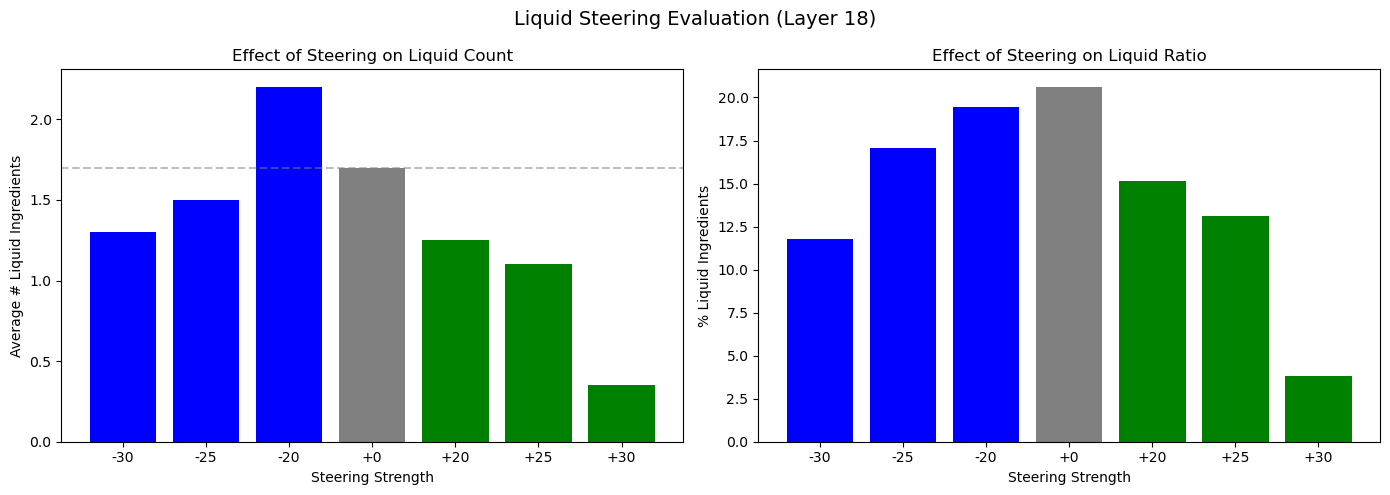


Summary:
Strength      Avg Liquids    Avg Total     Liquid %
--------------------------------------------------
-30                    1.30        11.05        11.8%
-25                    1.50         8.80        17.0%
-20                    2.20        11.30        19.5%
+0                    1.70         8.25        20.6%
+20                    1.25         8.25        15.2%
+25                    1.10         8.40        13.1%
+30                    0.35         9.20         3.8%


In [24]:
# Visualize results
strengths = sorted(eval_results.keys())
avg_liquids = [np.mean([r['predicted_liquids'] for r in eval_results[s]]) for s in strengths]
avg_total = [np.mean([r['predicted_total'] for r in eval_results[s]]) for s in strengths]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Liquid count
colors = ['blue' if s < 0 else ('gray' if s == 0 else 'green') for s in strengths]
axes[0].bar(range(len(strengths)), avg_liquids, color=colors)
axes[0].set_xticks(range(len(strengths)))
axes[0].set_xticklabels([f"{s:+.0f}" for s in strengths])
axes[0].set_xlabel('Steering Strength')
axes[0].set_ylabel('Average # Liquid Ingredients')
axes[0].set_title('Effect of Steering on Liquid Count')
axes[0].axhline(y=avg_liquids[len(strengths)//2], color='gray', linestyle='--', alpha=0.5, label='Baseline')

# Liquid ratio
liquid_ratios = [avg_liquids[i] / avg_total[i] * 100 if avg_total[i] > 0 else 0 for i in range(len(strengths))]
axes[1].bar(range(len(strengths)), liquid_ratios, color=colors)
axes[1].set_xticks(range(len(strengths)))
axes[1].set_xticklabels([f"{s:+.0f}" for s in strengths])
axes[1].set_xlabel('Steering Strength')
axes[1].set_ylabel('% Liquid Ingredients')
axes[1].set_title('Effect of Steering on Liquid Ratio')

plt.suptitle(f'Liquid Steering Evaluation (Layer {steering_layer})', fontsize=14)
plt.tight_layout()
plt.show()

# Summary stats
print("\nSummary:")
print(f"{'Strength':<12} {'Avg Liquids':>12} {'Avg Total':>12} {'Liquid %':>12}")
print("-" * 50)
for i, s in enumerate(strengths):
    print(f"{s:+.0f}{'':<11} {avg_liquids[i]:>12.2f} {avg_total[i]:>12.2f} {liquid_ratios[i]:>11.1f}%")

## 9. Save Results

In [ ]:
# Save probe and direction
save_data = {
    'liquids_set': LIQUIDS,
    'high_threshold': HIGH_THRESHOLD,
    'low_threshold': LOW_THRESHOLD,
    'directions_by_layer': directions,
    'accuracies_by_layer': accuracies,
    'best_layer': best_layer,
    'liquid_direction': liquid_direction,
}

save_path = "/home/s5e/jrosser.s5e/infusion/potions/liquid_probe.pkl"
with open(save_path, "wb") as f:
    pickle.dump(save_data, f)

print(f"Saved probe to: {save_path}")
print(f"\nBest layer: {best_layer}")
print(f"Test accuracy: {accuracies[best_layer][1]:.2%}")
print(f"\nTo use for steering:")
print(f"  Positive strength = MORE liquids")
print(f"  Negative strength = FEWER liquids")

## Summary

This notebook:
1. Defined 14 liquid ingredients vs 36 solid ingredients
2. Created contrastive dataset (high vs low liquid content)
3. Trained linear probes on all 33 layers
4. Found the best layer for liquid detection
5. Implemented activation steering to add/remove liquids
6. Evaluated steering effectiveness

**Key advantage over individual ingredient probing:**
- Tests an abstract semantic category ("liquidness")
- Not memorizing specific ingredients
- Should generalize better to steering